In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from tpot import TPOTClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, average_precision_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay
import utils

# Read data

In [4]:
df = pd.read_parquet('data-input/flirt-wesad-acc-bvp-eda-temp-60-10.parquet')

In [5]:
# remove columns (see EDA)
columns_to_drop = ['eda_EDA_n_sign_changes',
 'temp_TEMP_peaks',
 'acc_y_entropy',
 'acc_l2_n_sign_changes',
 'acc_x_entropy',
 'acc_z_entropy',
 'temp_l2_n_sign_changes',
 'bvp_BVP_entropy',
 'temp_TEMP_n_sign_changes',
 'temp_l2_peaks',
 'eda_l2_n_sign_changes']

df = df.drop(columns=columns_to_drop)

In [6]:
# split into train and test
df_train, df_test = utils.create_train_test(df, 5, 'subject', 'label')

X_train, y_train, groups_train = utils.split_df(df_train, 'subject', 'label')
X_test, y_test, groups_test = utils.split_df(df_test, 'subject', 'label')

# remove correlated features from train
X_train, selected_features = utils.remove_correlated_features(X_train, 0.8)

# remove the same columns from test
X_test = X_test[selected_features]

In [7]:
X_train.shape

(2208, 73)

In [8]:
X_test.shape

(551, 73)

In [22]:
X_train.columns

Index(['bvp_BVP_mean', 'bvp_BVP_std', 'bvp_BVP_sum', 'bvp_BVP_skewness',
       'bvp_BVP_kurtosis', 'bvp_BVP_peaks', 'bvp_BVP_n_above_mean',
       'bvp_BVP_n_below_mean', 'bvp_BVP_n_sign_changes',
       'bvp_BVP_perm_entropy', 'bvp_BVP_svd_entropy', 'bvp_l2_min',
       'bvp_l2_n_above_mean', 'bvp_l2_n_below_mean', 'bvp_l2_n_sign_changes',
       'bvp_l2_perm_entropy', 'acc_x_mean', 'acc_x_std', 'acc_x_ptp',
       'acc_x_energy', 'acc_x_skewness', 'acc_x_kurtosis', 'acc_x_peaks',
       'acc_x_lineintegral', 'acc_x_n_above_mean', 'acc_x_n_below_mean',
       'acc_x_n_sign_changes', 'acc_x_iqr', 'acc_y_mean', 'acc_y_std',
       'acc_y_min', 'acc_y_max', 'acc_y_energy', 'acc_y_skewness',
       'acc_y_kurtosis', 'acc_y_peaks', 'acc_y_n_above_mean',
       'acc_y_n_sign_changes', 'acc_y_svd_entropy', 'acc_z_mean', 'acc_z_std',
       'acc_z_min', 'acc_z_max', 'acc_z_energy', 'acc_z_skewness',
       'acc_z_kurtosis', 'acc_z_n_above_mean', 'acc_z_n_below_mean',
       'acc_z_n_sign_cha

In [10]:
# Check train and test set sizes
print('Percentage train set:', len(y_train)/(len(y_train)+len(y_test)))
print('Percentage test set:', len(y_test)/(len(y_train)+len(y_test)))

print('\nClass distribution in train set: \n', y_train['label'].value_counts(normalize=True), '\n')

print('Class distribution in test set: \n', y_test['label'].value_counts(normalize=True), '\n')

Percentage train set: 0.800289960130482
Percentage test set: 0.19971003986951794

Class distribution in train set: 
 label
0    0.637228
1    0.362772
Name: proportion, dtype: float64 

Class distribution in test set: 
 label
0    0.637024
1    0.362976
Name: proportion, dtype: float64 



# TPOT

In [11]:
tpot = TPOTClassifier(
    search_space="linear",  # or "linear-light" for faster execution
    scorers=['f1'],  # Use scorers instead of scoring
    cv=3,
    max_time_mins=6,  # Use max_time_mins instead of generations
    n_jobs=1,
    verbose=3,  # Use verbose instead of verbosity
    random_state=0
)

In [12]:
%%time
# Remove the groups parameter - it's not supported in this version
tpot.fit(X_train, y_train.values.ravel())

Generation: : 1it [01:35, 95.41s/it]

Generation:  1
Best f1_score score: 0.9931230427256735


Generation: : 2it [02:21, 66.58s/it]

Generation:  2
Best f1_score score: 0.9962452905070447


Generation: : 3it [03:16, 60.93s/it]

Generation:  3
Best f1_score score: 0.9962452905070447


Generation: : 4it [04:16, 60.56s/it]

Generation:  4
Best f1_score score: 0.9975031210986267


Generation: : 5it [05:14, 59.71s/it]

Generation:  5
Best f1_score score: 0.9981238273921201


Generation: : 6it [06:00, 60.12s/it]

Generation:  6
Best f1_score score: 0.9981238273921201


CPU times: user 46.8 s, sys: 5.13 s, total: 52 s
Wall time: 6min 3s


,search_space,<tpot.search_...t 0x1689176d0>
,scorers,['f1']
,scorers_weights,[1]
,cv,3
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True
,categorical_features,None
,memory,None
,preprocessing,False


In [18]:
print(f"TPOT score (F1) on test data: {f1_score(y_test.values.ravel(), tpot.predict(X_test)):.2f}")

TPOT score (F1) on test data: 0.76


In [20]:
y_test_predict = tpot.predict(X_test)
y_test_predict_proba = tpot.predict_proba(X_test)[:,1]

In [21]:
print('accuracy: '+str(accuracy_score(y_test, y_test_predict)))
print('precision: '+str(precision_score(y_test, y_test_predict)))
print('recall: '+str(recall_score(y_test, y_test_predict)))
print('f1_score: '+str(f1_score(y_test, y_test_predict)))
print('roc_auc: '+str(roc_auc_score(y_test, y_test_predict)))
print('Class distribution in test set: \n', y_test['label'].value_counts(normalize=True), '\n')
print('average_precision: '+str(average_precision_score(y_test, y_test_predict_proba)))

accuracy: 0.8511796733212341
precision: 0.9338235294117647
recall: 0.635
f1_score: 0.7559523809523809
roc_auc: 0.8046794871794871
Class distribution in test set: 
 label
0    0.637024
1    0.362976
Name: proportion, dtype: float64 

average_precision: 0.9286212484995757


In [16]:
confusion_matrix(y_test, y_test_predict)

array([[342,   9],
       [ 73, 127]])

The baseline to beat is the percentage of positive cases: 0.3629764065335753


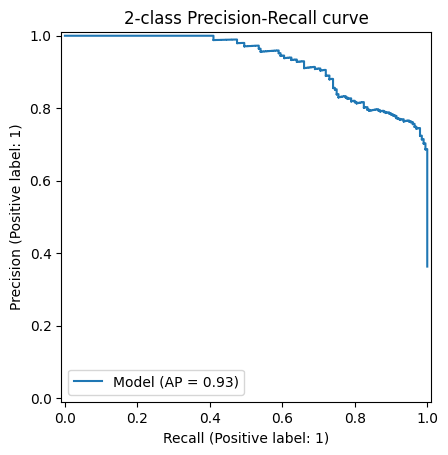

In [17]:
prd = PrecisionRecallDisplay.from_predictions(y_test, y_test_predict_proba, name='Model')
_ = prd.ax_.set_title('2-class Precision-Recall curve')
print('The baseline to beat is the percentage of positive cases:', y_test['label'].value_counts(normalize=True)[1])

## Interpretation
I created a TPOT baseline model in this notebook.

The data used was created with FLIRT with a window_size of 60 and a step size of 10.

The data of each user is either in the train or in the test set. Internally, TPOT does a cross-validation with the training data, and again only uses the data of each user in either training or validation set.

Hyperparameters, i.e., aspects that could be changed in future iterations:

- Calculating the features with another library instead of FLIRT.
- Using different window_sizes and step sizes.
- Test if we can predict stress by only using a subset of the available sensors.

The results so far are very promising: TPOT returned a pipeline with a performance on the test set of F1=0.68.